In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score ,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


In [3]:
data = pd.read_csv(r"C:\Users\USER\Downloads\earthquake_data_tsunami.csv")

In [4]:
data.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [5]:
data.isna().sum()

magnitude    0
cdi          0
mmi          0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
Year         0
Month        0
tsunami      0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.shape

(782, 13)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [9]:
data.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [10]:
data.groupby('tsunami').mean()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month
tsunami,,,,,,,,,,,,
0,6.942803,3.928870,6.135983,874.092050,349.933054,0.617095,22.792448,69.667356,6.001553,65.461177,2009.133891,6.625523
1,6.938487,4.970395,5.694079,863.845395,42.065789,2.440036,28.571382,85.656796,-0.335356,32.401155,2017.226974,6.467105


**Exploratory Data Analysis**

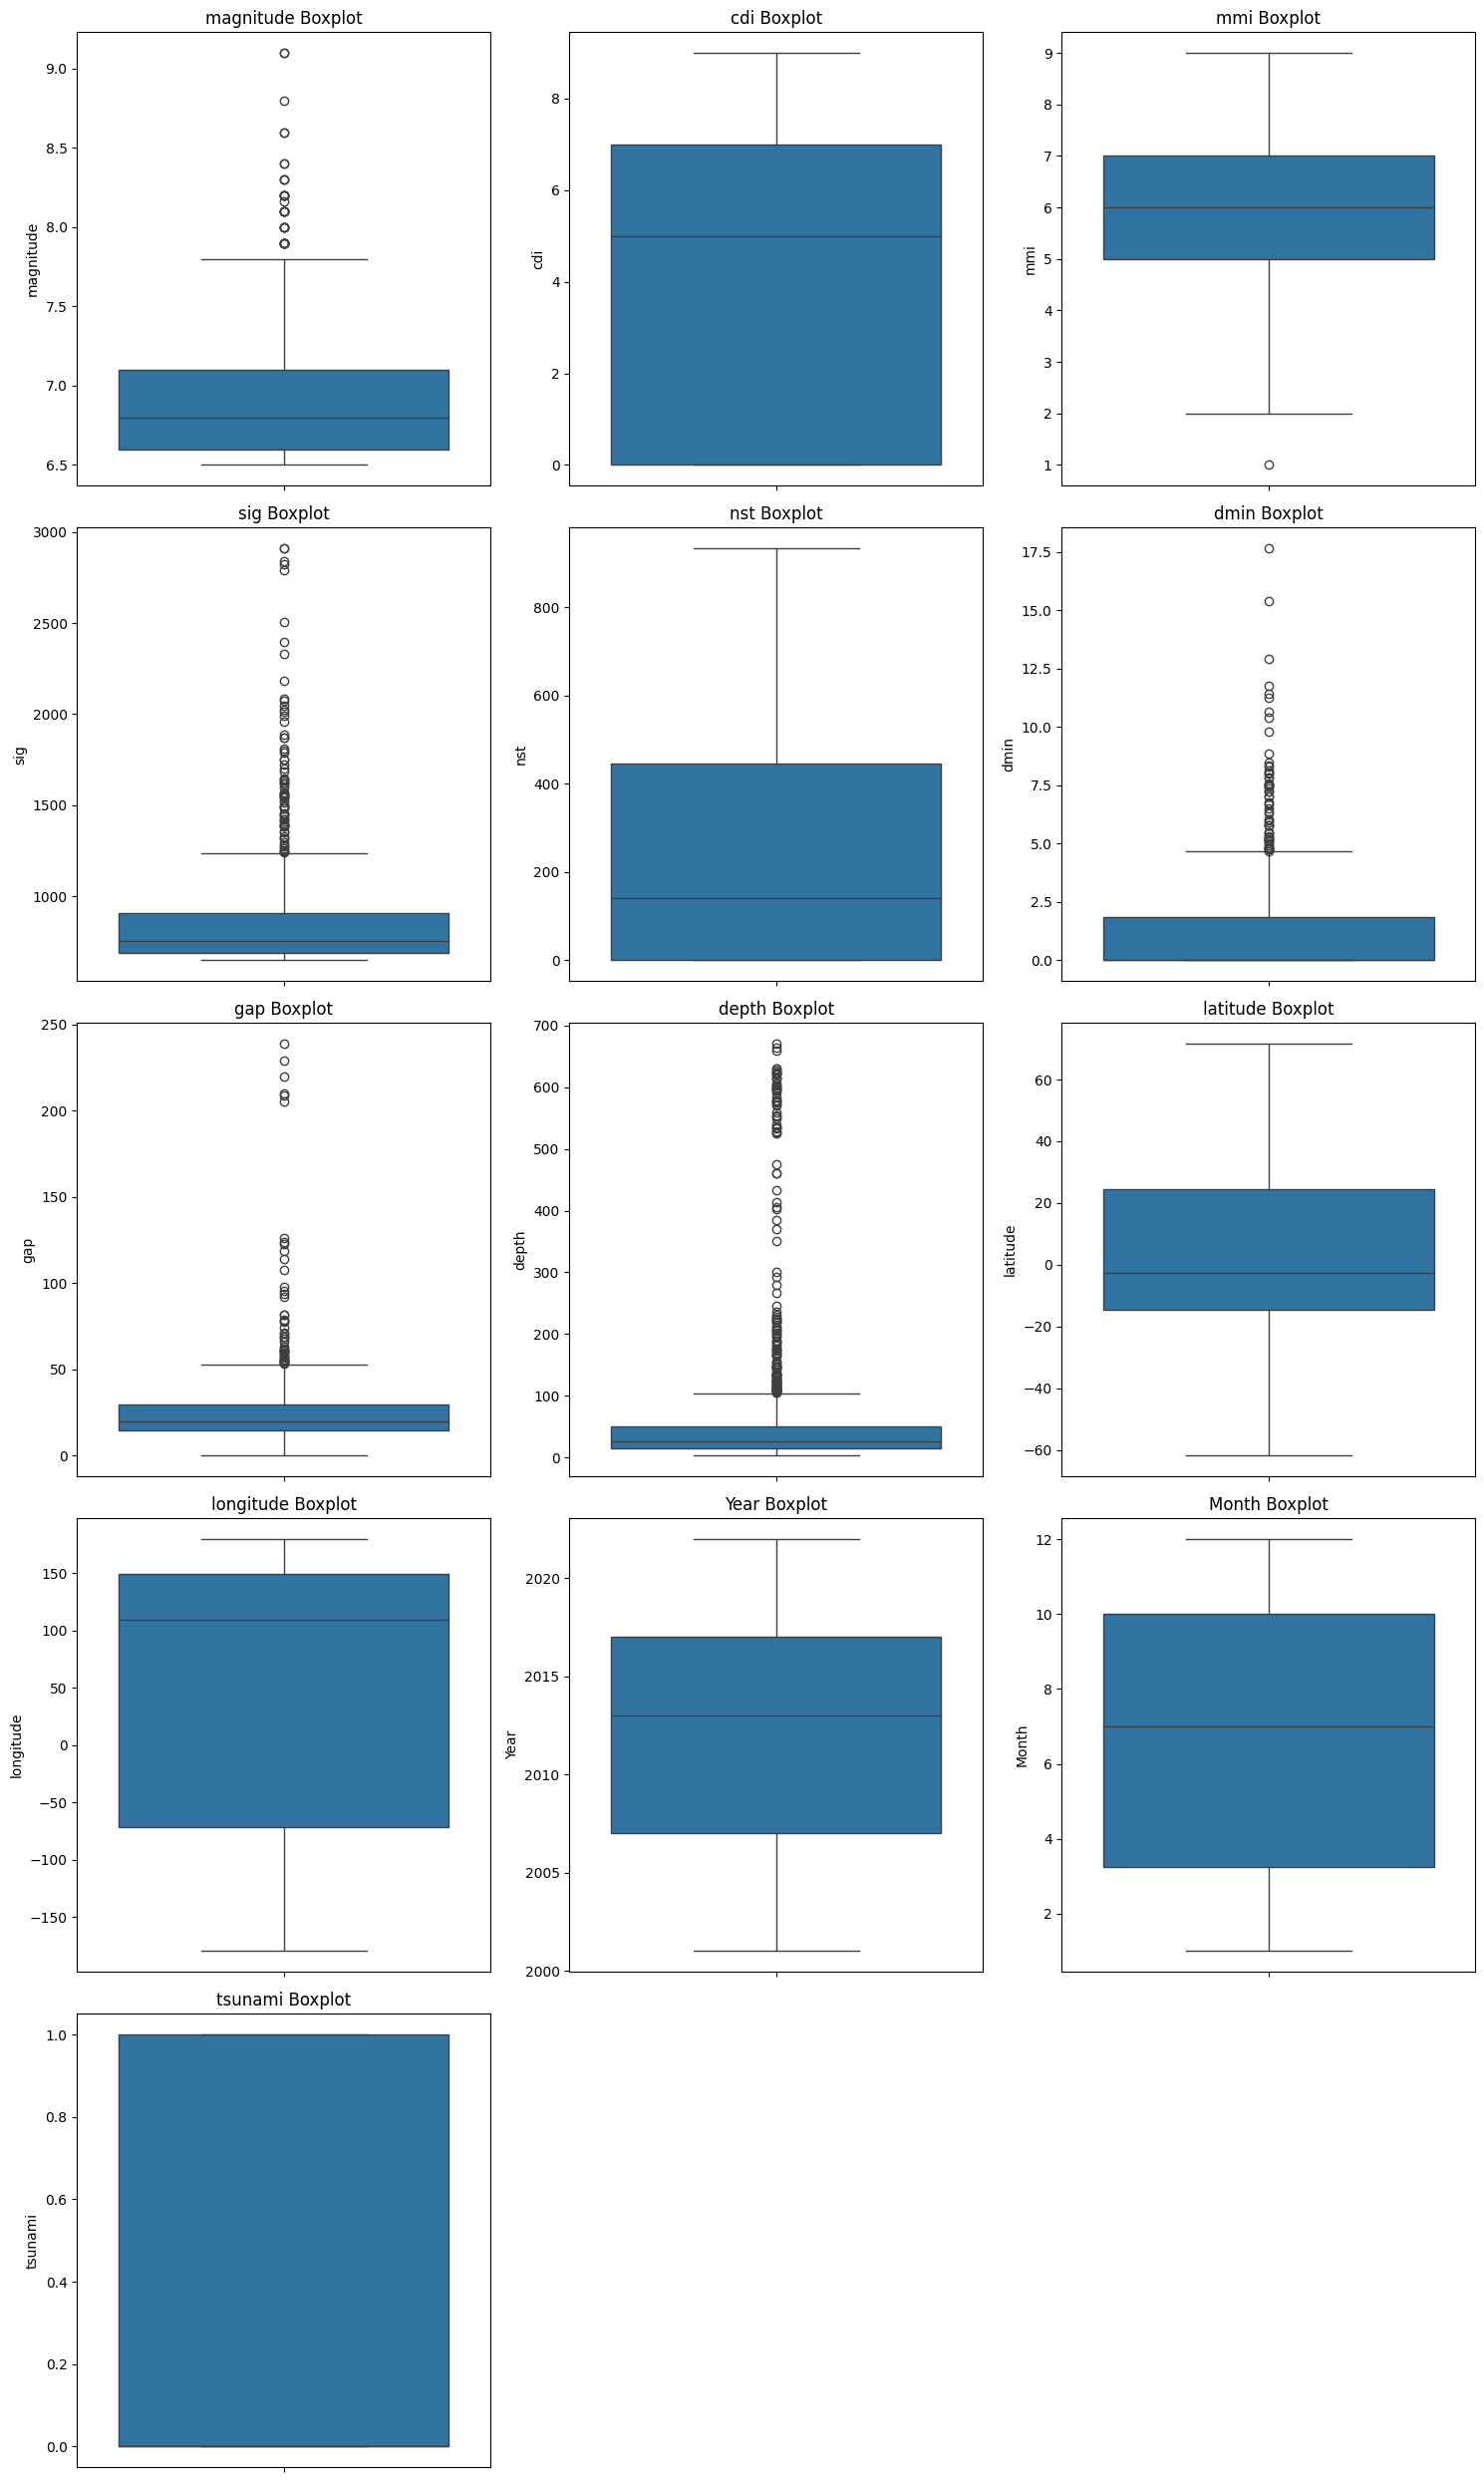

In [54]:
# Create subplots in a grid
numeric_cols = data.select_dtypes(include=[int, float]).columns
n_cols = len(numeric_cols)

# Calculate grid dimensions
n_rows = (n_cols + 2) // 3  # 3 columns per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for idx, col in enumerate(numeric_cols):
    if idx < len(axes):
        sns.boxplot(data=data, y=col, ax=axes[idx])
        axes[idx].set_title(f"{col} Boxplot")
    
# Hide empty subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
data.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')

In [11]:
# IQR method
cols_outliers = ['magnitude', 'sig','dmin', 'gap', 'depth']

for col in cols_outliers: 
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    upperbound = Q3 + 1.5*IQR
    lowerbound = Q1 - 1.5 * IQR

    data[col]= data[col].clip(lowerbound, upperbound)
   
    
    

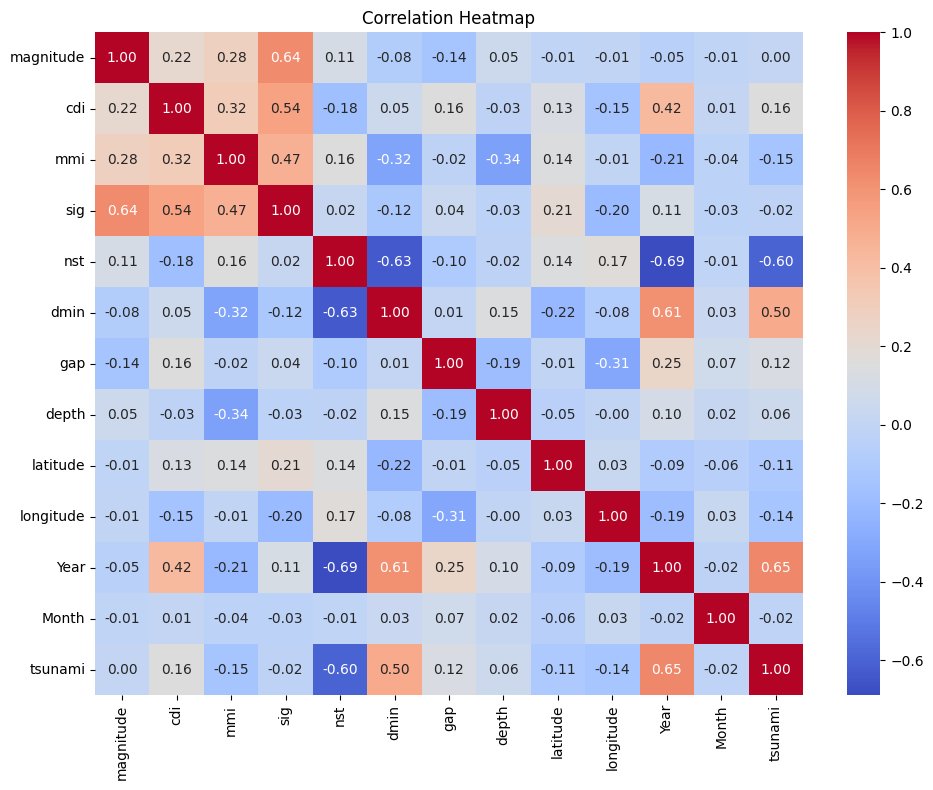

In [24]:


# Calculate correlation matrix
corr_matrix = data.corr(numeric_only = True)

# Basic heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

<Axes: xlabel='tsunami', ylabel='count'>

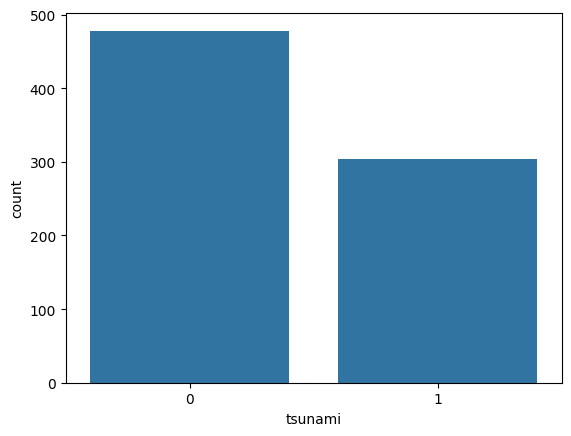

In [12]:
sns.countplot(data  = data, x = 'tsunami')

In [13]:
data.columns

Index(['magnitude', 'cdi', 'mmi', 'sig', 'nst', 'dmin', 'gap', 'depth',
       'latitude', 'longitude', 'Year', 'Month', 'tsunami'],
      dtype='object')

In [14]:
data

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768.0,117,0.5090,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735.0,99,2.2290,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755.0,147,3.1250,18.0,103.375,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833.0,149,1.8650,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670.0,131,4.6575,27.0,103.375,-25.5948,178.278,2022,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,7.7,0,8,912.0,427,0.0000,0.0,60.000,13.0490,-88.660,2001,1,0
778,6.9,5,7,745.0,0,0.0000,0.0,36.400,56.7744,-153.281,2001,1,0
779,7.1,0,7,776.0,372,0.0000,0.0,103.000,-14.9280,167.170,2001,1,0
780,6.8,0,5,711.0,64,0.0000,0.0,33.000,6.6310,126.899,2001,1,0


In [15]:
X = data.drop('tsunami', axis = 1)
Y = data['tsunami']

In [16]:
def encode_month_cyclic(X):
    X = X.copy()
    X["Month_sin"] = np.sin(2 * np.pi * X["Month"] / 12)
    X["Month_cos"] = np.cos(2 * np.pi * X["Month"] / 12)
    return X.drop(columns=["Month"])
    
month_cyclic = FunctionTransformer(encode_month_cyclic)

preprocessor = Pipeline(steps=[
    ("month_cyclic", month_cyclic),  # encode month
    ("scaler", StandardScaler())     # scale numeric + encoded features
])

In [33]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(criterion = 'entropy', random_state = 43),
    "Gradient Boosting": GradientBoostingClassifier(random_state = 43),
    "XGBoost Classifier": XGBClassifier(random_state = 43),
    "SVM": SVC(kernel = 'linear'),
    "KNN": KNeighborsClassifier()
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 43)

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_val_score(pipe,X, Y, cv = cv, scoring = 'accuracy' )

    print(f"\n{name}")
    print("Accuracies:", scores)
    print("Mean Accuracy:", scores.mean())
    print("Std Deviation:", scores.std())


Logistic Regression
Accuracies: [0.85350318 0.8343949  0.83974359 0.79487179 0.82692308]
Mean Accuracy: 0.8298873101420872
Std Deviation: 0.01954506164785797

Random Forest
Accuracies: [0.92356688 0.89171975 0.92948718 0.87820513 0.91666667]
Mean Accuracy: 0.9079291197125592
Std Deviation: 0.019656518895442947

Gradient Boosting
Accuracies: [0.93630573 0.9044586  0.92307692 0.92948718 0.94230769]
Mean Accuracy: 0.9271272252163973
Std Deviation: 0.01304248853026051

XGBoost Classifier
Accuracies: [0.92356688 0.91719745 0.94871795 0.91025641 0.92948718]
Mean Accuracy: 0.9258451739343458
Std Deviation: 0.013110387502569704

SVM
Accuracies: [0.84713376 0.82802548 0.81410256 0.79487179 0.8525641 ]
Mean Accuracy: 0.8273395394414502
Std Deviation: 0.021250562987489043

KNN
Accuracies: [0.84713376 0.81528662 0.81410256 0.78846154 0.8525641 ]
Mean Accuracy: 0.823509717458762
Std Deviation: 0.023608224124256894


**FINAL MODEL -> GRADIENT BOOST**

In [18]:
final_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state = 43))
])

X_train, X_test, Y_train , Y_test = train_test_split(X, Y, test_size = 0.2, stratify = Y, random_state = 43)

In [43]:
param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 4],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 3],
    'classifier__subsample': [0.8, 1.0],
    'classifier__max_features': ['sqrt', None]
}

random_search = RandomizedSearchCV(
    final_pipe,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring="accuracy",  # since it's regression
    n_jobs= 1,
    random_state=42
)

random_search.fit(X_train, Y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score (MSE):", random_search.best_score_)  # negative because sklearn flips the sign


Best Parameters: {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 3, 'classifier__max_features': None, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.2}
Best Score (MSE): 0.9119999999999999


In [44]:
best_param = random_search.best_params_

for para, value in best_param.items():
    print(f"{para}:{value}\n")

classifier__subsample:0.8

classifier__n_estimators:300

classifier__min_samples_split:2

classifier__min_samples_leaf:3

classifier__max_features:None

classifier__max_depth:4

classifier__learning_rate:0.2



In [29]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(learning_rate = 0.2, n_estimators = 300, subsample = 0.8,
                                           min_samples_split = 2, min_samples_leaf = 3, max_depth = 4, random_state = 43))
])

final_model.fit(X_train, Y_train)
pred = final_model.predict(X_test)
y_pred_train = final_model.predict(X_train)

print(accuracy_score(Y_train,y_pred_train))
print(accuracy_score(Y_test, pred))
print(precision_score(Y_test, pred))
print(recall_score(Y_test, pred))

1.0
0.9299363057324841
0.9310344827586207
0.8852459016393442


In [57]:
new_data = pd.DataFrame({
    "magnitude": [7.0, 6.9, 7.0, 7.3, 6.6],
    "cdi": [8, 4, 3, 5, 0],
    "mmi": [7, 4, 3, 5, 2],
    "sig": [768, 735, 755, 833, 670],
    "nst": [117, 99, 147, 149, 131],
    "dmin": [0.509, 2.229, 3.125, 1.865, 4.998],
    "gap": [17.0, 34.0, 18.0, 21.0, 27.0],
    "depth": [14.000, 25.000, 579.000, 37.000, 624.464],
    "latitude": [-9.7963, -4.9559, -20.0508, -19.2918, -25.5948],
    "longitude": [159.596, 100.738, -178.346, -172.129, 178.278],
    "Year": [2022, 2022, 2022, 2022, 2022],
    "Month": [11, 11, 11, 11, 11]
})

new_data

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11


In [58]:

predictions = final_model.predict(new_data)

# Get prediction probabilities (optional)
probabilities = final_model.predict_proba(new_data)

# Display results
new_data["Predicted_Tsunami"] = predictions
new_data["Tsunami_Probability"] = probabilities[:, 1]  # probability of class 1

In [59]:
new_data

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,Predicted_Tsunami,Tsunami_Probability
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1,0.999999
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0,0.000007
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1,0.999998
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1,1.000000
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1,0.740962
